In [4]:
import numpy as np

# H2O first excited state ~70.3 au
num_steps = 8
excited_state_energy = 0.35
freq_scan = np.linspace(0.0, excited_state_energy, num_steps).round(decimals=3)

print("dipole.frequencies", freq_scan.tolist())


dipole.frequencies [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35]


In [9]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.lines import Line2D
import gecko

# Presentation-style plotting defaults.
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'legend.fontsize': 12,
    'figure.titlesize': 20,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})


def add_frequency_index_axis(ax, frequencies, max_ticks=12):
    vals = np.asarray(frequencies, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return None

    uniq = np.unique(np.round(vals, 12))
    if uniq.size == 0:
        return None

    step = max(1, int(np.ceil(uniq.size / max_ticks)))
    tick_vals = uniq[::step]
    idx_map = {float(v): i for i, v in enumerate(uniq)}

    top = ax.twiny()
    top.set_xlim(ax.get_xlim())
    top.set_xticks(tick_vals)
    top.set_xticklabels([str(idx_map[float(v)]) for v in tick_vals])
    top.set_xlabel('Frequency index')
    top.grid(False)
    return top


DATA_ROOT = Path('/gpfs/scratch/ahurtado/project_data/freq_dev/data/H2O')
TASK_SUBDIR = Path('f0-f0300_n32_p16') / 'task_1' / 'molresponse'


def pick_first_existing(paths):
    for p in paths:
        if p.exists() and p.is_dir():
            return p
    return None


def pick_latest_matching(root, patterns):
    matches = []
    for pat in patterns:
        matches.extend([p for p in root.glob(pat) if p.is_dir()])
    if not matches:
        return None
    return sorted(matches, key=lambda p: p.stat().st_mtime)[-1]


RUN_SPECS = [
    {
        'key': 'global_cyclic',
        'label': 'Global-cyclic ownership (baseline)',
        'exact': [DATA_ROOT / 'mra-f0.000-f0.300-n32'],
        'patterns': [],
    },
    {
        'key': 'channel_local',
        'label': 'Channel-local ownership',
        'exact': [DATA_ROOT / 'mra-f0.000-f0.300-n32-channel_local'],
        'patterns': [],
    },
    {
        'key': 'frequency_first',
        'label': 'Frequency-first ownership',
        'exact': [DATA_ROOT / 'mra-f0.000-f0.300-n32-frequency_first'],
        'patterns': ['*frequency_first*', '*frequency-first*'],
    },
    {
        'key': 'frequency_block',
        'label': 'Frequency-block ownership',
        'exact': [DATA_ROOT / 'mra-f0.000-f0.300-n32-frequency_block', DATA_ROOT / 'mra-f0.000-f0.300-n32-frequency-block'],
        'patterns': ['*frequency_block', '*frequency-block', '*freq*block'],
    },
    {
        'key': 'frequency_block_longchain',
        'label': 'Frequency-block ownership (long-chain)',
        'exact': [
            DATA_ROOT / 'mra-f0.000-f0.300-n32-frequency-block-longchain',
            DATA_ROOT / 'mra-f0.000-f0.300-n32-frequency_block_longchain',
            DATA_ROOT / 'mra-f0.000-f0.300-n32-longchain',
        ],
        'patterns': ['*frequency-block-longchain*', '*frequency_block_longchain*', '*longchain*', '*long-chain*'],
    },
    {
        'key': 'frequency_block_raman',
        'label': 'Frequency-block ownership (Raman run)',
        'exact': [
            DATA_ROOT / 'mra-f0.000-f0.300-n32-frequency-block-raman',
            DATA_ROOT / 'mra-f0.000-f0.300-n32-frequency_block_raman',
        ],
        'patterns': ['*frequency-block-raman*', '*frequency_block_raman*', '*raman*'],
    },
]

RUN_LABELS = {spec['key']: spec['label'] for spec in RUN_SPECS}
RUN_ORDER_PREF = [spec['key'] for spec in RUN_SPECS]

run_contexts = {}
for spec in RUN_SPECS:
    key = spec['key']
    run_root = pick_first_existing(spec['exact'])
    if run_root is None and spec['patterns']:
        run_root = pick_latest_matching(DATA_ROOT, spec['patterns'])
    if run_root is None:
        continue

    molresponse_dir = run_root / TASK_SUBDIR
    shards = sorted(molresponse_dir.glob('response_metadata.group*.json'))
    if not shards:
        print(f'Skipping {key}: no metadata shards yet under {molresponse_dir}')
        continue

    calc = None
    calc_error = None
    try:
        calc = gecko.load_calc(run_root)
    except Exception as exc:
        calc_error = str(exc)

    run_contexts[key] = {
        'run_root': run_root,
        'molresponse_dir': molresponse_dir,
        'shards': shards,
        'calc': calc,
        'calc_error': calc_error,
    }

RUN_ORDER = [k for k in RUN_ORDER_PREF if k in run_contexts]
if not RUN_ORDER:
    raise RuntimeError('No valid runs with metadata shards were found.')

PRIMARY_RUN_CANDIDATES = ['frequency_block_longchain', 'frequency_block', 'frequency_first', 'channel_local', 'global_cyclic']
PRIMARY_RUN = next((k for k in PRIMARY_RUN_CANDIDATES if k in RUN_ORDER), RUN_ORDER[-1])
REFERENCE_RUN = 'global_cyclic' if 'global_cyclic' in RUN_ORDER else RUN_ORDER[0]

print('Loaded runs:', RUN_ORDER)
print('Primary run for detailed plots:', PRIMARY_RUN)
print('Reference run for timing deltas:', REFERENCE_RUN)
print()

for key in RUN_ORDER:
    ctx = run_contexts[key]
    print('Run key:', key)
    print('Run label:', RUN_LABELS.get(key, key))
    print('Run root:', ctx['run_root'])
    print('Molresponse shard count:', len(ctx['shards']))
    if ctx['calc'] is None:
        print('Gecko calc load: failed')
        print('Gecko calc error:', ctx['calc_error'])
    else:
        print('Gecko data keys:', sorted(ctx['calc'].data.keys()))
    print()



Loaded runs: ['global_cyclic', 'channel_local', 'frequency_first', 'frequency_block', 'frequency_block_longchain', 'frequency_block_raman']
Primary run for detailed plots: frequency_block_longchain
Reference run for timing deltas: global_cyclic

Run key: global_cyclic
Run label: Global-cyclic ownership (baseline)
Run root: /gpfs/scratch/ahurtado/project_data/freq_dev/data/H2O/mra-f0.000-f0.300-n32
Molresponse shard count: 16
Gecko data keys: ['alpha', 'beta', 'hessian', 'input_molecule', 'molecule', 'normal_modes', 'orbital_energies', 'output_molecule', 'polarization_frequencies', 'raman', 'raw_json', 'timings', 'vibrational_frequencies']

Run key: channel_local
Run label: Channel-local ownership
Run root: /gpfs/scratch/ahurtado/project_data/freq_dev/data/H2O/mra-f0.000-f0.300-n32-channel_local
Molresponse shard count: 16
Gecko data keys: ['alpha', 'beta', 'hessian', 'input_molecule', 'molecule', 'normal_modes', 'orbital_energies', 'output_molecule', 'polarization_frequencies', 'raman'

In [10]:
# Build point-level data tables for all runs (data retained for cross-run comparisons).
def build_point_table(shards):
    records = {}

    for shard in shards:
        gid = int(shard.stem.split('group')[-1])
        data = json.loads(shard.read_text())
        for state_id, state_payload in data.get('states', {}).items():
            for protocol_key, protocol_payload in (state_payload.get('protocols', {}) or {}).items():
                converged_map = protocol_payload.get('converged', {}) or {}
                saved_map = protocol_payload.get('saved', {}) or {}
                diag_map = protocol_payload.get('solver_diagnostics', {}) or {}
                prov_map = protocol_payload.get('restart_provenance', {}) or {}
                timing_map = protocol_payload.get('timings', {}) or {}

                owned_point_keys = set(diag_map.keys()) | set(prov_map.keys()) | set(timing_map.keys())
                all_point_keys = set(converged_map.keys()) | set(saved_map.keys()) | owned_point_keys

                for freq_str in all_point_keys:
                    key = (state_id, protocol_key, freq_str)
                    row = records.setdefault(
                        key,
                        {
                            'state': state_id,
                            'protocol': protocol_key,
                            'frequency': float(freq_str),
                            'saved': False,
                            'converged': False,
                            'iterations': np.nan,
                            'final_residual': np.nan,
                            'final_drho': np.nan,
                            'wall_seconds': np.nan,
                            'cpu_seconds': np.nan,
                            'restart_kind': 'unknown',
                            'groups': set(),
                        },
                    )

                    if freq_str in owned_point_keys:
                        row['groups'].add(gid)

                    row['saved'] = row['saved'] or bool(saved_map.get(freq_str, False))
                    row['converged'] = row['converged'] or bool(converged_map.get(freq_str, False))

                    diag = diag_map.get(freq_str)
                    if isinstance(diag, dict):
                        if diag.get('iterations_performed') is not None:
                            row['iterations'] = float(diag['iterations_performed'])
                        if diag.get('final_residual_norm') is not None:
                            row['final_residual'] = float(diag['final_residual_norm'])
                        if diag.get('final_density_change') is not None:
                            row['final_drho'] = float(diag['final_density_change'])

                    timing = timing_map.get(freq_str)
                    if isinstance(timing, dict):
                        if timing.get('wall_seconds') is not None:
                            row['wall_seconds'] = float(timing['wall_seconds'])
                        if timing.get('cpu_seconds') is not None:
                            row['cpu_seconds'] = float(timing['cpu_seconds'])

                    prov = prov_map.get(freq_str)
                    if isinstance(prov, dict):
                        kind = prov.get('kind')
                        if kind:
                            row['restart_kind'] = kind

    rows = []
    for row in records.values():
        row = dict(row)
        row['groups'] = sorted(row['groups'])
        row['owner_group'] = int(row['groups'][0]) if len(row['groups']) == 1 else np.nan
        rows.append(row)

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows).sort_values(['protocol', 'state', 'frequency']).reset_index(drop=True)
    channel_label = {'Dipole_x': 'DipoleX', 'Dipole_y': 'DipoleY', 'Dipole_z': 'DipoleZ'}
    df['channel'] = df['state'].map(channel_label).fillna(df['state'])
    return df


channel_order = ['DipoleX', 'DipoleY', 'DipoleZ']
channel_colors = {'DipoleX': '#1f77b4', 'DipoleY': '#2ca02c', 'DipoleZ': '#d62728'}
restart_markers = {
    'initial_guess': 'o',
    'coarser_protocol_archive': 's',
    'previous_frequency_archive': '^',
    'previous_frequency_memory': 'D',
    'same_protocol_archive': 'P',
    'unknown': 'X',
}

run_dfs = {}
for key in RUN_ORDER:
    df_run = build_point_table(run_contexts[key]['shards'])
    if df_run.empty:
        continue
    df_run['run_key'] = key
    df_run['run_label'] = RUN_LABELS.get(key, key)
    run_dfs[key] = df_run

if PRIMARY_RUN not in run_dfs:
    raise RuntimeError(f'Primary run {PRIMARY_RUN} has no parsed metadata rows.')

combined_df = pd.concat([run_dfs[key] for key in run_dfs], ignore_index=True)

summary_rows = []
for key in run_dfs:
    df = run_dfs[key]
    solved = int(np.isfinite(df['wall_seconds']).sum())
    converged = int(df['converged'].sum())
    total = len(df)
    summary_rows.append({
        'run_key': key,
        'run_label': RUN_LABELS.get(key, key),
        'points_total': total,
        'points_converged': converged,
        'points_with_timing': solved,
        'protocols': ', '.join(sorted(df['protocol'].unique(), key=float, reverse=True)),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print('Primary run protocols:', sorted(run_dfs[PRIMARY_RUN]['protocol'].unique(), key=float, reverse=True))



,run_key,run_label,points_total,points_converged,points_with_timing,protocols
0,global_cyclic,Global-cyclic ownership (baseline),192,192,192,"1e-03, 1e-04"
1,channel_local,Channel-local ownership,192,183,183,"1e-03, 1e-04"
2,frequency_first,Frequency-first ownership,192,192,192,"1e-03, 1e-04"
3,frequency_block,Frequency-block ownership,192,192,192,"1e-03, 1e-04"
4,frequency_block_longchain,Frequency-block ownership (long-chain),192,192,192,"1e-03, 1e-04"
5,frequency_block_raman,Frequency-block ownership (Raman run),210,210,210,"1e-03, 1e-04"


Primary run protocols: ['1e-03', '1e-04']


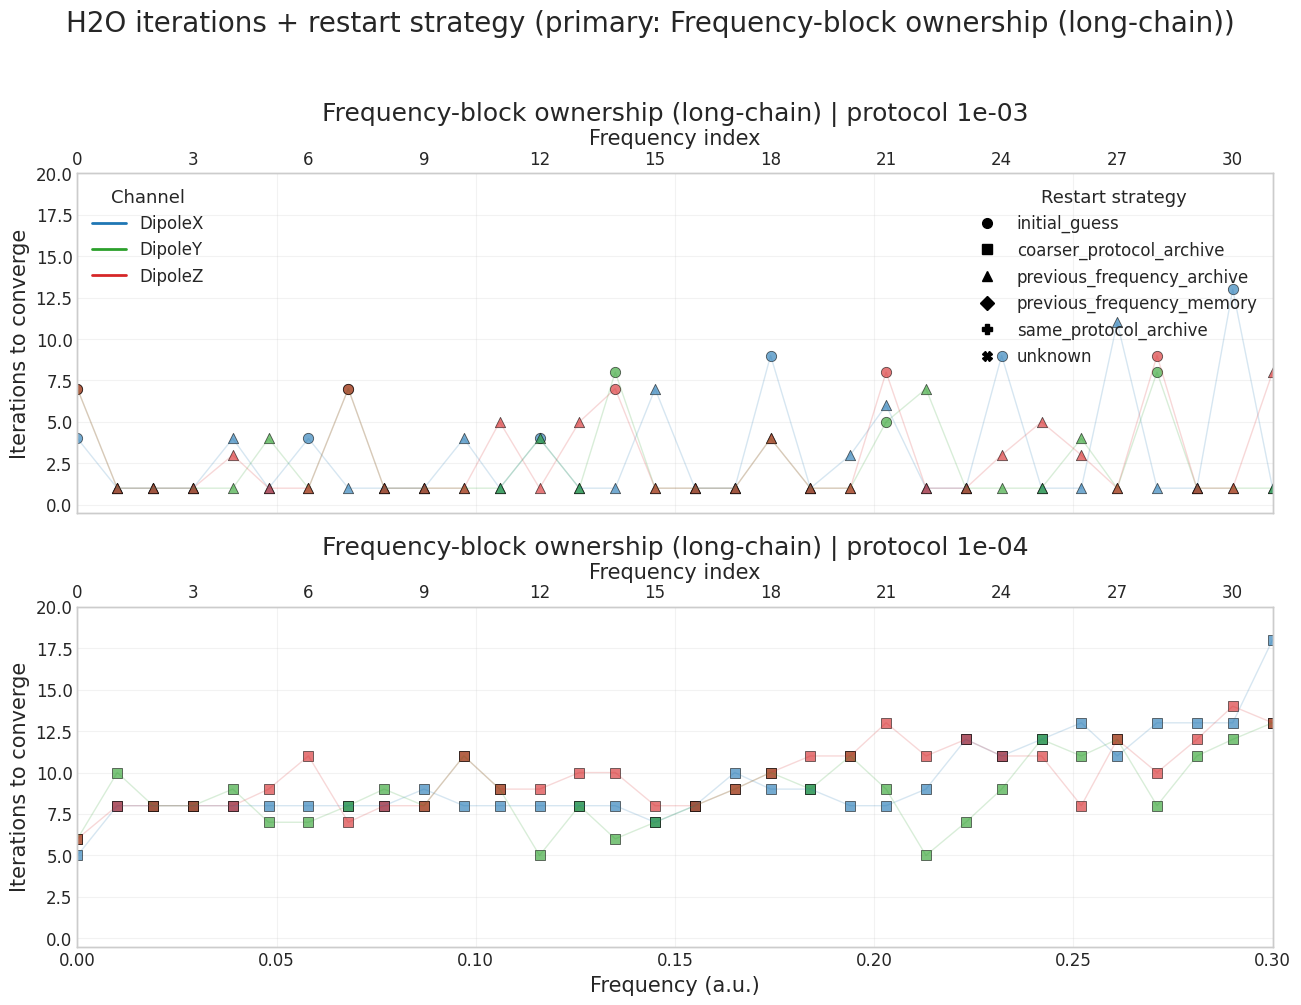

In [11]:
# Primary-run plot: iterations vs frequency with restart strategy markers.
primary_key = PRIMARY_RUN
df = run_dfs[primary_key]
protocols = sorted(df['protocol'].unique(), key=float, reverse=True)

iter_vals = df['iterations'].to_numpy(dtype=float)
iter_vals = iter_vals[np.isfinite(iter_vals)]
iter_max = float(iter_vals.max()) if iter_vals.size else 1.0
iter_upper = max(5.0, np.ceil(iter_max * 1.10))

freq_vals = df['frequency'].to_numpy(dtype=float)
freq_vals = freq_vals[np.isfinite(freq_vals)]
x_min = float(freq_vals.min()) if freq_vals.size else 0.0
x_max = float(freq_vals.max()) if freq_vals.size else 1.0

fig, axes = plt.subplots(
    len(protocols),
    1,
    figsize=(13.2, 5.0 * len(protocols)),
    sharex=True,
    sharey=True,
)
if len(protocols) == 1:
    axes = [axes]

for ax, protocol in zip(axes, protocols):
    sub = df[df['protocol'] == protocol].copy()

    for channel in channel_order:
        sub_ch = sub[sub['channel'] == channel]
        if sub_ch.empty:
            continue

        sub_ch_sorted = sub_ch.sort_values('frequency')
        ax.plot(
            sub_ch_sorted['frequency'],
            sub_ch_sorted['iterations'],
            color=channel_colors[channel],
            linewidth=1.0,
            alpha=0.18,
        )

        for strategy, marker in restart_markers.items():
            sub_sel = sub_ch[sub_ch['restart_kind'] == strategy]
            if sub_sel.empty:
                continue

            converged = sub_sel[sub_sel['converged']]
            unconverged = sub_sel[~sub_sel['converged']]

            if not converged.empty:
                ax.scatter(
                    converged['frequency'],
                    converged['iterations'],
                    c=channel_colors[channel],
                    marker=marker,
                    s=55,
                    alpha=0.62,
                    linewidths=0.6,
                    edgecolors='black',
                )
            if not unconverged.empty:
                ax.scatter(
                    unconverged['frequency'],
                    unconverged['iterations'],
                    c='none',
                    edgecolors=channel_colors[channel],
                    marker=marker,
                    s=85,
                    linewidths=1.4,
                    alpha=0.9,
                )

    ax.set_title(f"{RUN_LABELS.get(primary_key, primary_key)} | protocol {protocol}")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-0.5, iter_upper)
    ax.set_ylabel('Iterations to converge')
    ax.grid(alpha=0.25)
    add_frequency_index_axis(ax, sub['frequency'].to_numpy())

axes[-1].set_xlabel('Frequency (a.u.)')

channel_handles = [
    Line2D([0], [0], color=channel_colors[ch], lw=2, label=ch)
    for ch in channel_order
]
restart_handles = [
    Line2D([0], [0], marker=m, color='black', linestyle='None', markersize=7, label=k)
    for k, m in restart_markers.items()
]

legend1 = axes[0].legend(handles=channel_handles, title='Channel', loc='upper left')
axes[0].add_artist(legend1)
axes[0].legend(handles=restart_handles, title='Restart strategy', loc='upper right', ncol=1)

plt.suptitle(f"H2O iterations + restart strategy (primary: {RUN_LABELS.get(primary_key, primary_key)})", y=1.005)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()



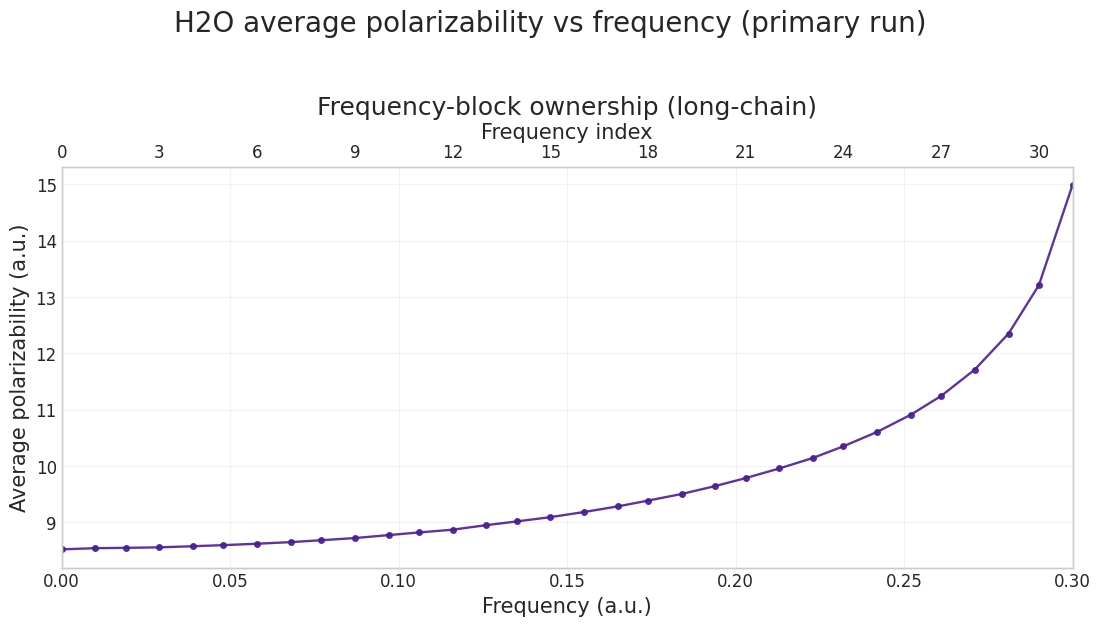

In [12]:
# Primary-run plot: average polarizability vs frequency.
def extract_alpha_profile(calc):
    alpha = calc.data.get('alpha')
    if not isinstance(alpha, dict) or not alpha:
        return None

    omega_raw = alpha.get('omega', [])
    values_raw = alpha.get('values', [])
    components = [str(c).lower() for c in alpha.get('components', [])]

    omega = np.asarray(omega_raw, dtype=float).reshape(-1)
    values = np.asarray(values_raw, dtype=float)

    if omega.size == 0 or values.size == 0:
        return None

    if values.ndim == 1:
        if len(components) > 0 and (values.size % len(components) == 0):
            values = values.reshape(-1, len(components))
        elif omega.size > 0 and (values.size % omega.size == 0):
            values = values.reshape(omega.size, -1)
        else:
            return None

    if values.shape[0] != omega.size:
        if values.ndim == 2 and values.shape[1] == omega.size:
            values = values.T
        else:
            return None

    if len(components) and len(components) == values.shape[1]:
        component_to_idx = {c: i for i, c in enumerate(components)}
        if not all(c in component_to_idx for c in ('xx', 'yy', 'zz')):
            return None
        idx_xx, idx_yy, idx_zz = component_to_idx['xx'], component_to_idx['yy'], component_to_idx['zz']
    elif values.shape[1] >= 9:
        idx_xx, idx_yy, idx_zz = 0, 4, 8
    else:
        return None

    alpha_avg = (values[:, idx_xx] + values[:, idx_yy] + values[:, idx_zz]) / 3.0
    return omega, alpha_avg


primary_key = PRIMARY_RUN
primary_ctx = run_contexts[primary_key]
calc = primary_ctx.get('calc')
profile = extract_alpha_profile(calc) if calc is not None else None

fig, ax = plt.subplots(1, 1, figsize=(11.2, 6.2))
if profile is None:
    missing_msg = primary_ctx.get('calc_error') or 'No parseable alpha data in this run yet.'
    ax.text(
        0.5,
        0.5,
        missing_msg,
        ha='center',
        va='center',
        transform=ax.transAxes,
        fontsize=12,
        wrap=True,
    )
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
else:
    omega, alpha_avg = profile
    ax.plot(
        omega,
        alpha_avg,
        color='#4c1d95',
        marker='o',
        markersize=4,
        linewidth=1.7,
        alpha=0.90,
    )
    ax.set_xlim(float(np.min(omega)), float(np.max(omega)))
    y_min, y_max = float(np.min(alpha_avg)), float(np.max(alpha_avg))
    y_pad = 0.05 * (y_max - y_min) if (y_max - y_min) > 1e-12 else 0.05
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    add_frequency_index_axis(ax, omega)

ax.set_title(RUN_LABELS.get(primary_key, primary_key))
ax.set_xlabel('Frequency (a.u.)')
ax.set_ylabel('Average polarizability (a.u.)')
ax.grid(alpha=0.25)
plt.suptitle('H2O average polarizability vs frequency (primary run)', y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()



/tmp/ipykernel_571342/3491960970.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


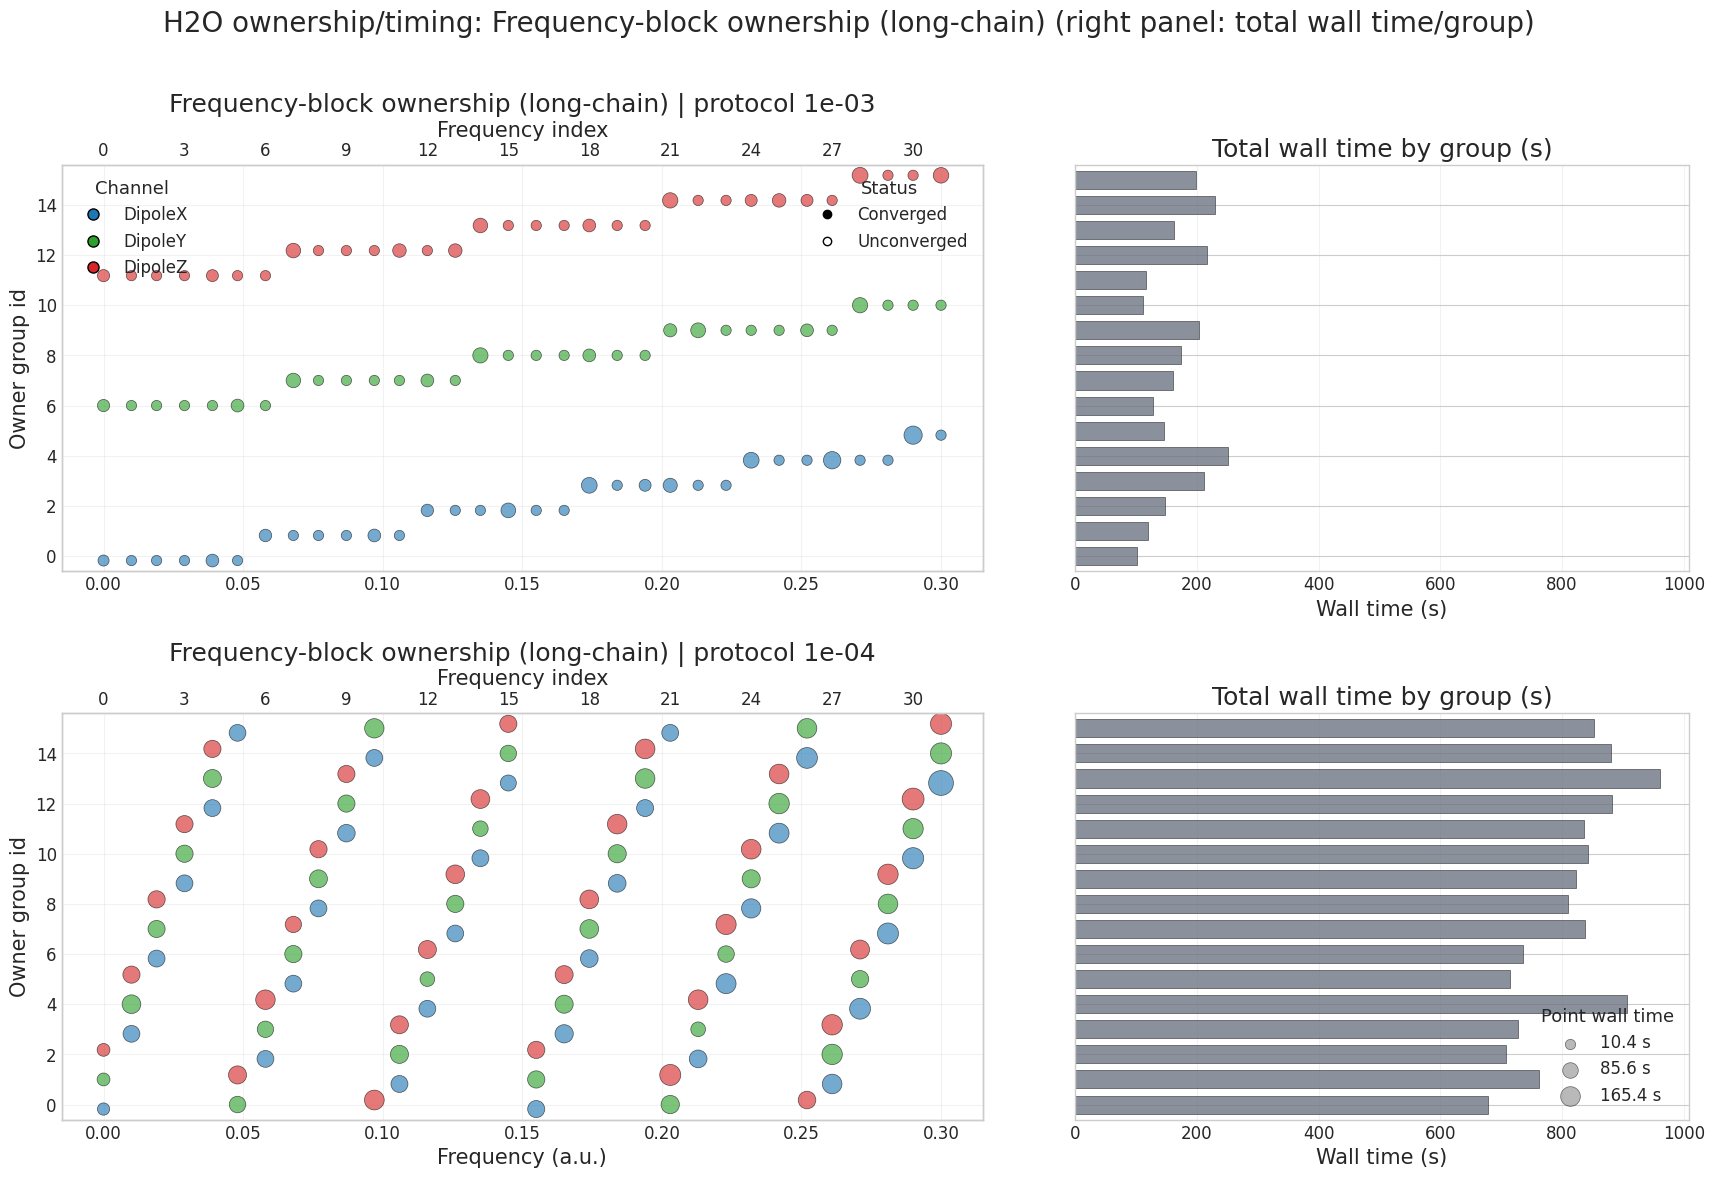

In [13]:
# Primary-run ownership + per-group total wall-time plot.
primary_key = PRIMARY_RUN
df = run_dfs[primary_key].dropna(subset=['owner_group', 'wall_seconds']).copy()

if df.empty:
    raise RuntimeError(f'No ownership/timing rows found for primary run {primary_key}.')

df['owner_group'] = df['owner_group'].astype(int)
protocols = sorted(df['protocol'].unique(), key=float, reverse=True)
owner_groups = sorted(df['owner_group'].unique().tolist())
wall_min = float(df['wall_seconds'].min())
wall_max = float(df['wall_seconds'].max())
y_min = min(owner_groups) - 0.6
y_max = max(owner_groups) + 0.6

bar_max = float(df.groupby(['protocol', 'owner_group'])['wall_seconds'].sum().max())
bar_max = max(bar_max, 1e-9)


def point_size(values):
    vals = np.asarray(values, dtype=float)
    if not np.isfinite(wall_max - wall_min) or (wall_max - wall_min) < 1e-12:
        return np.full_like(vals, 90.0)
    return 55.0 + 265.0 * ((vals - wall_min) / (wall_max - wall_min))


fig = plt.figure(figsize=(21, 6.2 * len(protocols)))
grid = fig.add_gridspec(
    nrows=len(protocols),
    ncols=2,
    width_ratios=[3.6, 2.4],
    wspace=0.12,
    hspace=0.35,
)

scatter_axes = []
bar_axes = []

for i, protocol in enumerate(protocols):
    ax = fig.add_subplot(grid[i, 0])
    ax_bar = fig.add_subplot(grid[i, 1], sharey=ax)
    scatter_axes.append(ax)
    bar_axes.append(ax_bar)

    sub = df[df['protocol'] == protocol].copy()

    for channel in channel_order:
        ch = sub[sub['channel'] == channel].sort_values('frequency')
        if ch.empty:
            continue

        y = ch['owner_group'].to_numpy(dtype=float) + {'DipoleX': -0.18, 'DipoleY': 0.0, 'DipoleZ': 0.18}[channel]
        sizes = point_size(ch['wall_seconds'])
        conv = ch['converged'].to_numpy(dtype=bool)

        if conv.any():
            ax.scatter(
                ch.loc[conv, 'frequency'],
                y[conv],
                s=sizes[conv],
                c=channel_colors[channel],
                alpha=0.62,
                edgecolors='black',
                linewidths=0.5,
            )

        if (~conv).any():
            ax.scatter(
                ch.loc[~conv, 'frequency'],
                y[~conv],
                s=sizes[~conv],
                facecolors='none',
                edgecolors=channel_colors[channel],
                alpha=0.95,
                linewidths=1.3,
            )

    totals = (
        sub.groupby('owner_group')['wall_seconds']
        .sum()
        .reindex(owner_groups, fill_value=0.0)
    )

    ax_bar.barh(
        owner_groups,
        totals.values,
        color='#6b7280',
        alpha=0.78,
        height=0.72,
        edgecolor='black',
        linewidth=0.4,
    )

    ax.set_ylim(y_min, y_max)
    ax_bar.set_ylim(y_min, y_max)
    ax_bar.set_xlim(0.0, 1.05 * bar_max)

    ax.set_title(f"{RUN_LABELS.get(primary_key, primary_key)} | protocol {protocol}")
    ax.set_ylabel('Owner group id')
    ax.grid(alpha=0.25)
    add_frequency_index_axis(ax, sub['frequency'].to_numpy())

    ax_bar.set_title('Total wall time by group (s)')
    ax_bar.set_xlabel('Wall time (s)')
    ax_bar.grid(axis='x', alpha=0.25)
    ax_bar.tick_params(axis='y', labelleft=False)

scatter_axes[-1].set_xlabel('Frequency (a.u.)')

channel_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=channel_colors[ch],
           markeredgecolor='black', markersize=8, label=ch)
    for ch in channel_order
]
status_handles = [
    Line2D([0], [0], marker='o', color='black', markerfacecolor='black', linestyle='None', label='Converged'),
    Line2D([0], [0], marker='o', color='black', markerfacecolor='none', linestyle='None', label='Unconverged'),
]

legend1 = scatter_axes[0].legend(handles=channel_handles, title='Channel', loc='upper left')
scatter_axes[0].add_artist(legend1)
scatter_axes[0].legend(handles=status_handles, title='Status', loc='upper right')

q = np.quantile(df['wall_seconds'].to_numpy(dtype=float), [0.25, 0.5, 0.9])
size_handles = [
    plt.scatter([], [], s=point_size(np.array([v]))[0], color='gray', alpha=0.55,
                edgecolors='black', linewidths=0.5, label=f'{v:.1f} s')
    for v in q
]
bar_axes[-1].legend(handles=size_handles, title='Point wall time', loc='lower right', ncol=1)

plt.suptitle(
    f"H2O ownership/timing: {RUN_LABELS.get(primary_key, primary_key)} (right panel: total wall time/group)",
    y=1.005,
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()



,run_key,run_label,total_wall_s,critical_path_est_s,points_with_timing,avg_wall_per_point_s
0,global_cyclic,Global-cyclic ownership (baseline),18034.302796,1359.809890,192,93.928660
1,channel_local,Channel-local ownership,16991.716144,1268.161622,183,92.850908
2,frequency_first,Frequency-first ownership,17998.972380,1259.436154,192,93.744648
3,frequency_block,Frequency-block ownership,15749.695237,1480.501057,192,82.029663
4,frequency_block_longchain,Frequency-block ownership (long-chain),15641.426167,1211.581795,192,81.465761
5,frequency_block_raman,Frequency-block ownership (Raman run),17125.947191,1580.760670,210,81.552129


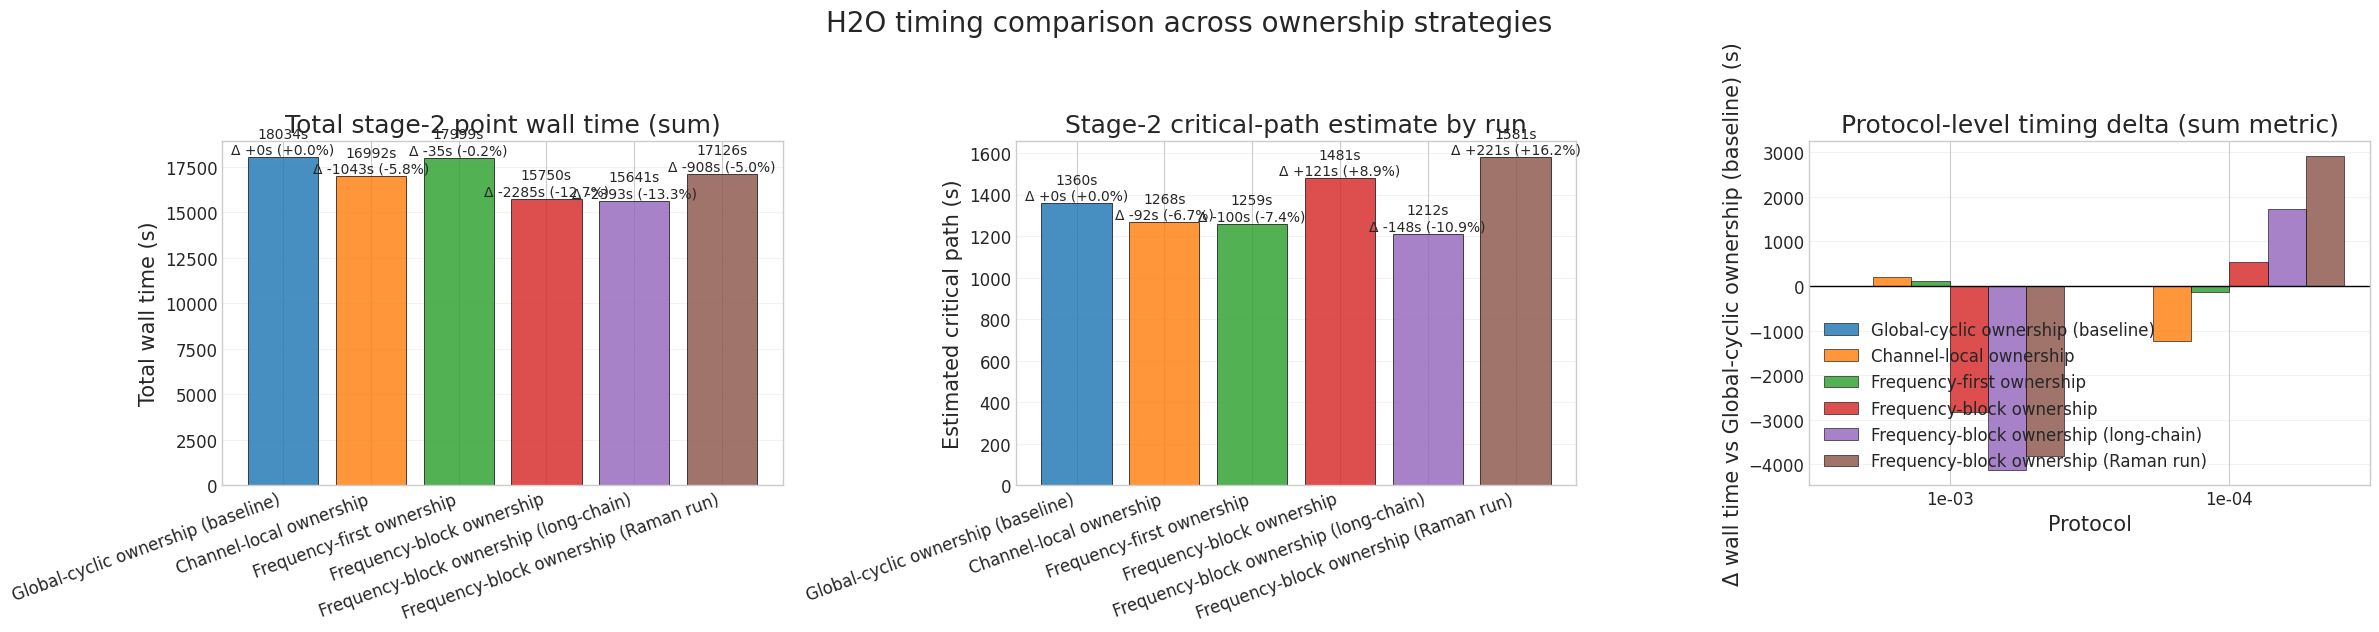

In [14]:
# Cross-run comparison: timing differences, total wall time, and critical-path estimate.
frames = []
for key, df in run_dfs.items():
    sub = df[np.isfinite(df['wall_seconds'])].copy()
    if sub.empty:
        continue
    sub['run_key'] = key
    frames.append(sub)

if not frames:
    raise RuntimeError('No wall-time rows available for comparison across runs.')

timing_df = pd.concat(frames, ignore_index=True)
timing_df['owner_group_num'] = pd.to_numeric(timing_df['owner_group'], errors='coerce')
protocol_order = sorted(timing_df['protocol'].unique(), key=float, reverse=True)
comparison_runs = [k for k in RUN_ORDER if k in timing_df['run_key'].unique()]

if len(comparison_runs) < 2:
    print('Only one run has timing data; skipping cross-run timing comparison plot.')
else:
    ref_key = REFERENCE_RUN if REFERENCE_RUN in comparison_runs else comparison_runs[0]

    totals_by_run = (
        timing_df.groupby('run_key')['wall_seconds']
        .sum()
        .reindex(comparison_runs)
    )

    protocol_totals = (
        timing_df.groupby(['run_key', 'protocol'])['wall_seconds']
        .sum()
        .unstack(fill_value=0.0)
        .reindex(index=comparison_runs, columns=protocol_order, fill_value=0.0)
    )

    # Critical-path estimate per protocol:
    # max subgroup-owned wall time across owner groups at that protocol.
    # For paths without owner-group tags, fall back to total protocol wall.
    protocol_critical = pd.DataFrame(0.0, index=comparison_runs, columns=protocol_order)
    for key in comparison_runs:
        for protocol_key in protocol_order:
            subp = timing_df[(timing_df['run_key'] == key) & (timing_df['protocol'] == protocol_key)]
            owned = subp[np.isfinite(subp['owner_group_num'])]
            if owned.empty:
                crit = float(subp['wall_seconds'].sum())
            else:
                crit = float(owned.groupby('owner_group_num')['wall_seconds'].sum().max())
            protocol_critical.loc[key, protocol_key] = crit

    critical_totals_by_run = protocol_critical.sum(axis=1)

    delta_vs_ref = protocol_totals.subtract(protocol_totals.loc[ref_key], axis=1)

    summary = pd.DataFrame({
        'run_key': comparison_runs,
        'run_label': [RUN_LABELS.get(k, k) for k in comparison_runs],
        'total_wall_s': [float(totals_by_run.loc[k]) for k in comparison_runs],
        'critical_path_est_s': [float(critical_totals_by_run.loc[k]) for k in comparison_runs],
        'points_with_timing': [int(np.isfinite(run_dfs[k]['wall_seconds']).sum()) for k in comparison_runs],
        'avg_wall_per_point_s': [
            float(run_dfs[k].loc[np.isfinite(run_dfs[k]['wall_seconds']), 'wall_seconds'].mean())
            for k in comparison_runs
        ],
    })
    display(summary)

    fig, axes = plt.subplots(1, 3, figsize=(24, 6.2))

    # Left: total point-wall by run (sum over all solved points).
    x = np.arange(len(comparison_runs))
    total_vals = totals_by_run.to_numpy(dtype=float)
    run_colors = [plt.cm.tab10(i % 10) for i in range(len(comparison_runs))]
    bars = axes[0].bar(
        x,
        total_vals,
        color=run_colors,
        alpha=0.82,
        edgecolor='black',
        linewidth=0.6,
    )
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([RUN_LABELS.get(k, k) for k in comparison_runs], rotation=20, ha='right')
    axes[0].set_ylabel('Total wall time (s)')
    axes[0].set_title('Total stage-2 point wall time (sum)')
    axes[0].grid(axis='y', alpha=0.25)

    ref_total = float(totals_by_run.loc[ref_key])
    for i, (bar, key) in enumerate(zip(bars, comparison_runs)):
        v = float(total_vals[i])
        d = v - ref_total
        d_pct = 0.0 if abs(ref_total) < 1e-12 else 100.0 * d / ref_total
        label = f"{v:.0f}s\nΔ {d:+.0f}s ({d_pct:+.1f}%)"
        axes[0].text(
            bar.get_x() + bar.get_width() / 2.0,
            bar.get_height(),
            label,
            ha='center',
            va='bottom',
            fontsize=10,
        )

    # Middle: critical-path estimate by run.
    crit_vals = critical_totals_by_run.reindex(comparison_runs).to_numpy(dtype=float)
    bars_crit = axes[1].bar(
        x,
        crit_vals,
        color=run_colors,
        alpha=0.82,
        edgecolor='black',
        linewidth=0.6,
    )
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([RUN_LABELS.get(k, k) for k in comparison_runs], rotation=20, ha='right')
    axes[1].set_ylabel('Estimated critical path (s)')
    axes[1].set_title('Stage-2 critical-path estimate by run')
    axes[1].grid(axis='y', alpha=0.25)

    ref_crit = float(critical_totals_by_run.loc[ref_key])
    for i, (bar, key) in enumerate(zip(bars_crit, comparison_runs)):
        v = float(crit_vals[i])
        d = v - ref_crit
        d_pct = 0.0 if abs(ref_crit) < 1e-12 else 100.0 * d / ref_crit
        label = f"{v:.0f}s\nΔ {d:+.0f}s ({d_pct:+.1f}%)"
        axes[1].text(
            bar.get_x() + bar.get_width() / 2.0,
            bar.get_height(),
            label,
            ha='center',
            va='bottom',
            fontsize=10,
        )

    # Right: protocol-level timing deltas vs reference (sum metric).
    xp = np.arange(len(protocol_order), dtype=float)
    n = len(comparison_runs)
    width = 0.82 / max(1, n)
    for i, key in enumerate(comparison_runs):
        vals = delta_vs_ref.loc[key, protocol_order].to_numpy(dtype=float)
        offset = (i - (n - 1) / 2.0) * width
        axes[2].bar(
            xp + offset,
            vals,
            width=width,
            label=RUN_LABELS.get(key, key),
            alpha=0.82,
            edgecolor='black',
            linewidth=0.5,
        )

    axes[2].axhline(0.0, color='black', linewidth=1.0)
    axes[2].set_xticks(xp)
    axes[2].set_xticklabels(protocol_order)
    axes[2].set_xlabel('Protocol')
    axes[2].set_ylabel(f'Δ wall time vs {RUN_LABELS.get(ref_key, ref_key)} (s)')
    axes[2].set_title('Protocol-level timing delta (sum metric)')
    axes[2].grid(axis='y', alpha=0.25)
    axes[2].legend(loc='best')

    plt.suptitle('H2O timing comparison across ownership strategies', y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()



In [15]:
# Slide controls for run-to-run timing and Raman comparisons.

def resolve_run_key(preferred_key, fallback_keys, available_keys):
    if preferred_key is not None and preferred_key in available_keys:
        return preferred_key
    for key in fallback_keys:
        if key in available_keys:
            return key
    return None

# Timing comparison controls (edit these if you want a different pair).
TIMING_TARGET_KEY = PRIMARY_RUN
TIMING_BASELINE_KEY = 'frequency_block' if 'frequency_block' in RUN_ORDER else REFERENCE_RUN

# Raman comparison controls.
# Keep baseline as None if you only want to inspect one Raman-enabled run.
TOP_RAMAN_PEAKS = 5

raman_ready_runs = []
for key in RUN_ORDER:
    calc = run_contexts[key].get('calc')
    if calc is None:
        continue
    raman_block = calc.data.get('raman') or {}
    raman_by_freq = raman_block.get('raman_by_freq') or {}
    if isinstance(raman_by_freq, dict) and len(raman_by_freq) > 0:
        raman_ready_runs.append(key)

RAMAN_TARGET_KEY = (
    'frequency_block_raman'
    if 'frequency_block_raman' in raman_ready_runs
    else (raman_ready_runs[0] if raman_ready_runs else None)
)
RAMAN_BASELINE_KEY = None


def extract_raman_frequency_df(run_key):
    if run_key is None or run_key not in run_contexts:
        return pd.DataFrame()
    calc = run_contexts[run_key].get('calc')
    if calc is None:
        return pd.DataFrame()

    raman_block = calc.data.get('raman') or {}
    raman_by_freq = raman_block.get('raman_by_freq') or {}
    if not isinstance(raman_by_freq, dict) or len(raman_by_freq) == 0:
        return pd.DataFrame()

    rows = []
    for freq_key, mode_rows in raman_by_freq.items():
        try:
            freq = float(freq_key)
        except Exception:
            continue

        mode_rows = mode_rows if isinstance(mode_rows, (list, tuple)) else []
        total_pol_int = 0.0
        total_depol_int = 0.0
        max_mode_pol_int = np.nan

        pol_vals = []
        for row in mode_rows:
            if not isinstance(row, dict):
                continue
            pol_val = float(row.get('pol_int', 0.0) or 0.0)
            depol_val = float(row.get('depol_int', 0.0) or 0.0)
            total_pol_int += pol_val
            total_depol_int += depol_val
            pol_vals.append(pol_val)

        if pol_vals:
            max_mode_pol_int = float(np.max(pol_vals))

        rows.append({
            'frequency': freq,
            'mode_count': len(mode_rows),
            'total_pol_int': total_pol_int,
            'total_depol_int': total_depol_int,
            'max_mode_pol_int': max_mode_pol_int,
        })

    if not rows:
        return pd.DataFrame()

    return pd.DataFrame(rows).sort_values('frequency').reset_index(drop=True)


timing_target_key = resolve_run_key(TIMING_TARGET_KEY, [PRIMARY_RUN, REFERENCE_RUN], RUN_ORDER)
timing_baseline_key = resolve_run_key(
    TIMING_BASELINE_KEY,
    [REFERENCE_RUN, RUN_ORDER[0] if RUN_ORDER else None],
    RUN_ORDER,
)
if timing_baseline_key is None:
    timing_baseline_key = timing_target_key

raman_target_key = resolve_run_key(RAMAN_TARGET_KEY, raman_ready_runs, raman_ready_runs)
if RAMAN_BASELINE_KEY is None:
    raman_baseline_key = None
else:
    raman_baseline_key = resolve_run_key(
        RAMAN_BASELINE_KEY,
        [k for k in raman_ready_runs if k != raman_target_key],
        raman_ready_runs,
    )

raman_freq_df_by_run = {
    key: extract_raman_frequency_df(key)
    for key in raman_ready_runs
}

print('Timing target run:', timing_target_key)
print('Timing baseline run:', timing_baseline_key)
print('Raman-enabled runs:', raman_ready_runs)
print('Raman target run:', raman_target_key)
print('Raman baseline run:', raman_baseline_key)



Timing target run: frequency_block_longchain
Timing baseline run: frequency_block
Raman-enabled runs: ['frequency_block_raman']
Raman target run: frequency_block_raman
Raman baseline run: None


,run_key,run_label,points_with_timing,total_sum_wall_s,total_critical_path_est_s,avg_wall_per_point_s
0,frequency_block,Frequency-block ownership,192,15749.695237,1480.501057,82.029663
1,frequency_block_longchain,Frequency-block ownership (long-chain),192,15641.426167,1211.581795,81.465761


,protocol,baseline_sum_wall_s,target_sum_wall_s,baseline_critical_s,target_critical_s,delta_sum_wall_s,delta_critical_s
0,1e-03,3967.252233,2683.314968,339.631496,250.835972,-1283.937264,-88.795524
1,1e-04,11782.443004,12958.111199,1140.869561,960.745822,1175.668195,-180.123738


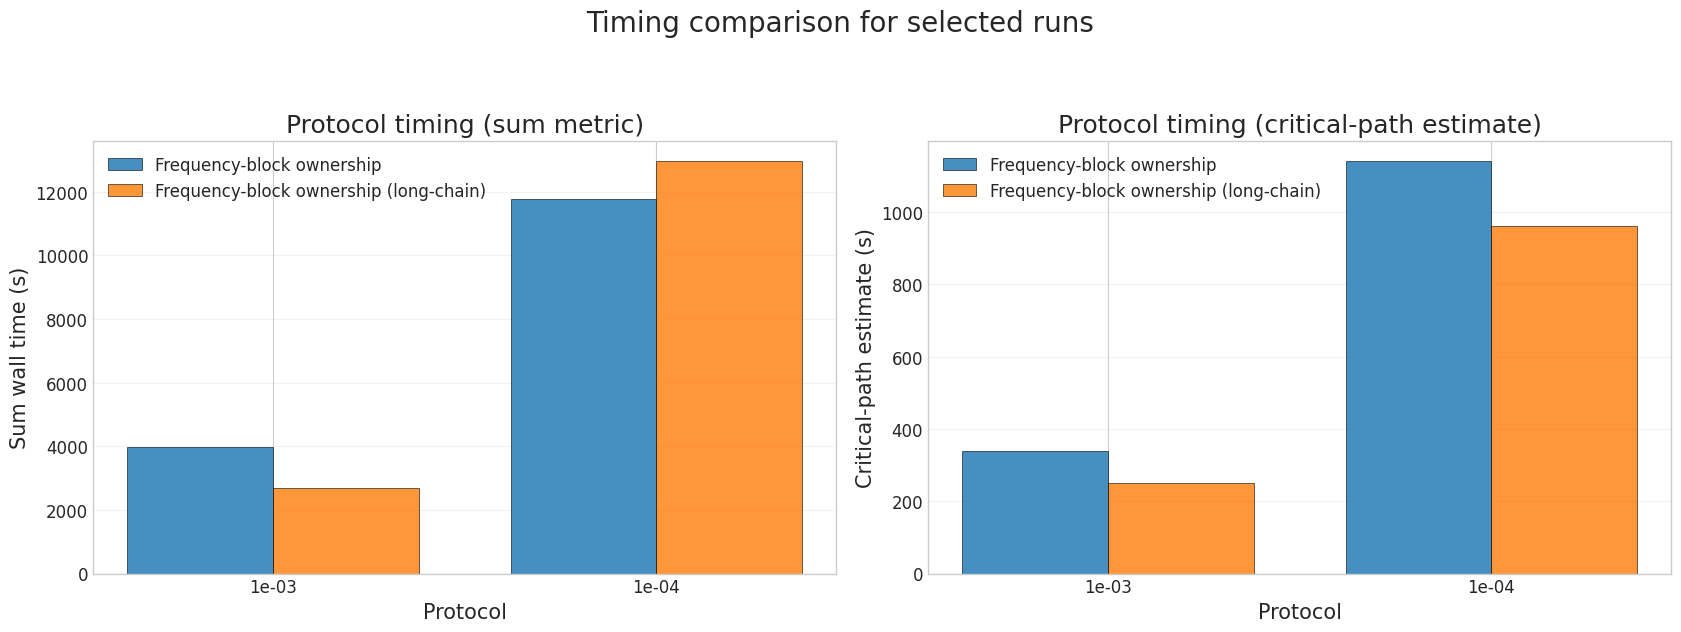

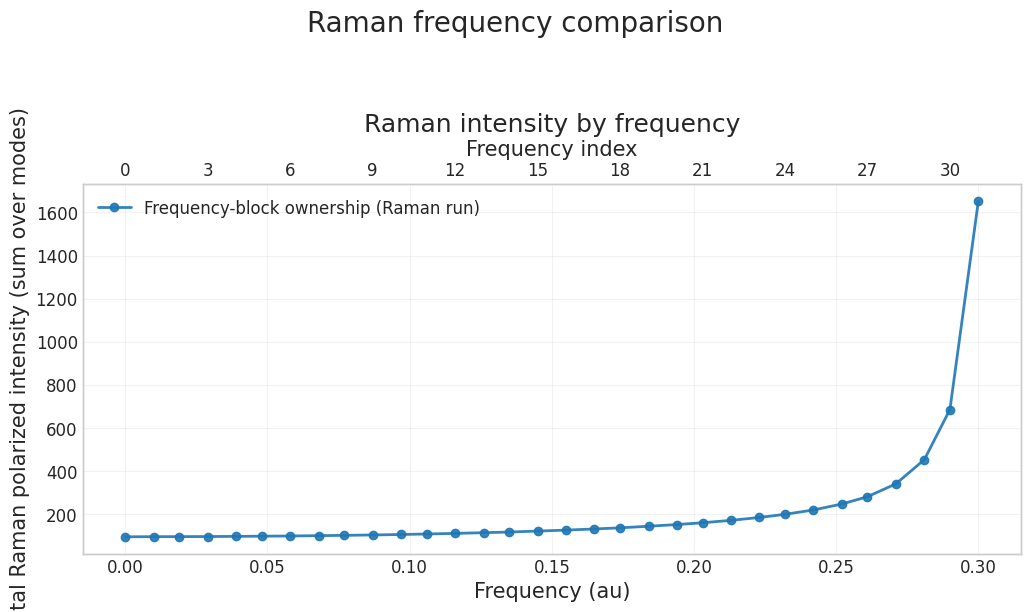

,frequency,total_pol_int,mode_count,max_mode_pol_int
0,0.300,1652.903586,3,1590.525466
1,0.290,685.949189,3,632.207600
2,0.281,453.836439,3,406.262760
3,0.271,341.542071,3,299.386585
4,0.261,282.041323,3,244.267997


In [16]:
# Timing + Raman comparison slides (run pair controlled in the previous cell).

def compute_protocol_timing_tables(run_key):
    df = run_dfs[run_key].copy()
    df = df[np.isfinite(df['wall_seconds'])].copy()
    if df.empty:
        return pd.Series(dtype=float), pd.Series(dtype=float), 0

    protocol_totals = df.groupby('protocol')['wall_seconds'].sum()

    df['owner_group_num'] = pd.to_numeric(df['owner_group'], errors='coerce')
    protocol_critical = {}
    for protocol_key, sub in df.groupby('protocol'):
        owned = sub[np.isfinite(sub['owner_group_num'])]
        if owned.empty:
            protocol_critical[protocol_key] = float(sub['wall_seconds'].sum())
        else:
            protocol_critical[protocol_key] = float(
                owned.groupby('owner_group_num')['wall_seconds'].sum().max()
            )

    return protocol_totals, pd.Series(protocol_critical), len(df)


if timing_target_key is None:
    raise RuntimeError('No timing target run resolved.')

base_protocol_totals, base_protocol_critical, base_points = compute_protocol_timing_tables(timing_baseline_key)
tgt_protocol_totals, tgt_protocol_critical, tgt_points = compute_protocol_timing_tables(timing_target_key)

protocol_keys = sorted(
    set(base_protocol_totals.index) | set(tgt_protocol_totals.index),
    key=float,
    reverse=True,
)

protocol_compare_df = pd.DataFrame({
    'protocol': protocol_keys,
    'baseline_sum_wall_s': [float(base_protocol_totals.get(p, 0.0)) for p in protocol_keys],
    'target_sum_wall_s': [float(tgt_protocol_totals.get(p, 0.0)) for p in protocol_keys],
    'baseline_critical_s': [float(base_protocol_critical.get(p, 0.0)) for p in protocol_keys],
    'target_critical_s': [float(tgt_protocol_critical.get(p, 0.0)) for p in protocol_keys],
})
protocol_compare_df['delta_sum_wall_s'] = (
    protocol_compare_df['target_sum_wall_s'] - protocol_compare_df['baseline_sum_wall_s']
)
protocol_compare_df['delta_critical_s'] = (
    protocol_compare_df['target_critical_s'] - protocol_compare_df['baseline_critical_s']
)

overview_df = pd.DataFrame([
    {
        'run_key': timing_baseline_key,
        'run_label': RUN_LABELS.get(timing_baseline_key, timing_baseline_key),
        'points_with_timing': int(base_points),
        'total_sum_wall_s': float(base_protocol_totals.sum()),
        'total_critical_path_est_s': float(base_protocol_critical.sum()),
        'avg_wall_per_point_s': float(base_protocol_totals.sum() / base_points) if base_points > 0 else np.nan,
    },
    {
        'run_key': timing_target_key,
        'run_label': RUN_LABELS.get(timing_target_key, timing_target_key),
        'points_with_timing': int(tgt_points),
        'total_sum_wall_s': float(tgt_protocol_totals.sum()),
        'total_critical_path_est_s': float(tgt_protocol_critical.sum()),
        'avg_wall_per_point_s': float(tgt_protocol_totals.sum() / tgt_points) if tgt_points > 0 else np.nan,
    },
])

display(overview_df)
display(protocol_compare_df)

x = np.arange(len(protocol_keys), dtype=float)
width = 0.38
fig, axes = plt.subplots(1, 2, figsize=(17, 6.2))

# Protocol sum-wall comparison.
axes[0].bar(
    x - width / 2,
    [float(base_protocol_totals.get(p, 0.0)) for p in protocol_keys],
    width=width,
    label=RUN_LABELS.get(timing_baseline_key, timing_baseline_key),
    alpha=0.82,
    edgecolor='black',
    linewidth=0.5,
)
axes[0].bar(
    x + width / 2,
    [float(tgt_protocol_totals.get(p, 0.0)) for p in protocol_keys],
    width=width,
    label=RUN_LABELS.get(timing_target_key, timing_target_key),
    alpha=0.82,
    edgecolor='black',
    linewidth=0.5,
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(protocol_keys)
axes[0].set_xlabel('Protocol')
axes[0].set_ylabel('Sum wall time (s)')
axes[0].set_title('Protocol timing (sum metric)')
axes[0].grid(axis='y', alpha=0.25)
axes[0].legend(loc='best')

# Protocol critical-path estimate comparison.
axes[1].bar(
    x - width / 2,
    [float(base_protocol_critical.get(p, 0.0)) for p in protocol_keys],
    width=width,
    label=RUN_LABELS.get(timing_baseline_key, timing_baseline_key),
    alpha=0.82,
    edgecolor='black',
    linewidth=0.5,
)
axes[1].bar(
    x + width / 2,
    [float(tgt_protocol_critical.get(p, 0.0)) for p in protocol_keys],
    width=width,
    label=RUN_LABELS.get(timing_target_key, timing_target_key),
    alpha=0.82,
    edgecolor='black',
    linewidth=0.5,
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(protocol_keys)
axes[1].set_xlabel('Protocol')
axes[1].set_ylabel('Critical-path estimate (s)')
axes[1].set_title('Protocol timing (critical-path estimate)')
axes[1].grid(axis='y', alpha=0.25)
axes[1].legend(loc='best')

plt.suptitle('Timing comparison for selected runs', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Raman frequency-wise comparison.
raman_target_df = raman_freq_df_by_run.get(raman_target_key, pd.DataFrame())
raman_baseline_df = raman_freq_df_by_run.get(raman_baseline_key, pd.DataFrame()) if raman_baseline_key is not None else pd.DataFrame()

if raman_target_df.empty:
    print('No Raman frequency data available for the selected Raman target run.')
else:
    has_baseline = not raman_baseline_df.empty

    if has_baseline:
        fig, axes = plt.subplots(1, 2, figsize=(18, 6.0))
        ax0, ax1 = axes
    else:
        fig, ax0 = plt.subplots(1, 1, figsize=(10.5, 6.0))
        ax1 = None

    ax0.plot(
        raman_target_df['frequency'],
        raman_target_df['total_pol_int'],
        marker='o',
        linewidth=2.0,
        alpha=0.9,
        label=RUN_LABELS.get(raman_target_key, raman_target_key),
    )
    if has_baseline:
        ax0.plot(
            raman_baseline_df['frequency'],
            raman_baseline_df['total_pol_int'],
            marker='s',
            linewidth=1.8,
            alpha=0.8,
            label=RUN_LABELS.get(raman_baseline_key, raman_baseline_key),
        )

    ax0.set_xlabel('Frequency (au)')
    ax0.set_ylabel('Total Raman polarized intensity (sum over modes)')
    ax0.set_title('Raman intensity by frequency')
    ax0.grid(alpha=0.25)
    ax0.legend(loc='best')
    add_frequency_index_axis(ax0, raman_target_df['frequency'])

    peak_table = raman_target_df.sort_values('total_pol_int', ascending=False).head(TOP_RAMAN_PEAKS).copy()

    if has_baseline:
        merged = raman_target_df[['frequency', 'total_pol_int']].rename(columns={'total_pol_int': 'target_pol_int'}).merge(
            raman_baseline_df[['frequency', 'total_pol_int']].rename(columns={'total_pol_int': 'baseline_pol_int'}),
            on='frequency',
            how='left',
        )
        merged['baseline_pol_int'] = merged['baseline_pol_int'].fillna(0.0)
        merged['delta_pol_int'] = merged['target_pol_int'] - merged['baseline_pol_int']

        denom = np.where(np.abs(merged['baseline_pol_int']) > 1.0e-12, merged['baseline_pol_int'], np.nan)
        merged['delta_pol_int_pct'] = 100.0 * merged['delta_pol_int'] / denom

        delta_curve = merged.sort_values('frequency')
        ax1.plot(
            delta_curve['frequency'],
            delta_curve['delta_pol_int'],
            color='#d62728',
            marker='o',
            linewidth=1.8,
            alpha=0.9,
        )
        ax1.axhline(0.0, color='black', linewidth=1.0)
        ax1.set_xlabel('Frequency (au)')
        ax1.set_ylabel('Δ Raman polarized intensity')
        ax1.set_title(
            f"Raman delta: {RUN_LABELS.get(raman_target_key, raman_target_key)} - {RUN_LABELS.get(raman_baseline_key, raman_baseline_key)}"
        )
        ax1.grid(alpha=0.25)
        add_frequency_index_axis(ax1, delta_curve['frequency'])

        peak_table = peak_table.merge(
            merged[['frequency', 'baseline_pol_int', 'delta_pol_int', 'delta_pol_int_pct']],
            on='frequency',
            how='left',
        )

    plt.suptitle('Raman frequency comparison', y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    peak_cols = ['frequency', 'total_pol_int', 'mode_count', 'max_mode_pol_int']
    if 'baseline_pol_int' in peak_table.columns:
        peak_cols.extend(['baseline_pol_int', 'delta_pol_int', 'delta_pol_int_pct'])
    display(peak_table[peak_cols].sort_values('total_pol_int', ascending=False).reset_index(drop=True))

